## CIFAR-10 Image Classification with Convolutional Neural Networks (CNNs)
In this notebook we will build a CNN to classify images from the CIFAR-10 dataset.

In [35]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.regularizers import l2
from keras import backend as K
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras import layers, regularizers, Model, Input
from keras.optimizers import Adam


Load the CIFAR-10 dataset and split it into training and test sets. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

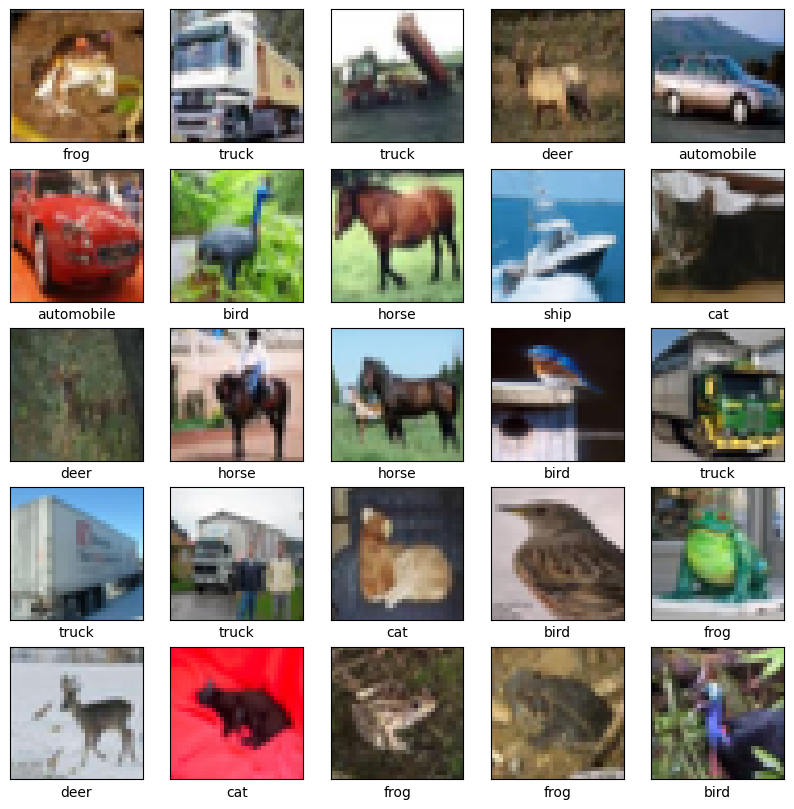

In [36]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()


Scale the pixel values to be between 0 and 1 by dividing by 255.0. Also, convert the class labels to one-hot encoded vectors. The input shape of the images is (32, 32, 3) since they are 32x32 pixels with 3 color channels (RGB). The number of classes is 10, corresponding to the 10 different categories in the CIFAR-10 dataset.

In [37]:
# Define the number of classes in the dataset
num_classes = 10
# Define the input shape of the images
input_shape = (32, 32, 3)

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert class vectors to binary class matrices (one-hot encoding)
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Print the shapes of the training and test sets
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


Next we will build the CNN model using Keras. The architecture will consist of 4 convolutional blocks, each followed by batch normalization, ReLU activation, max pooling, and dropout for regularization. After the convolutional blocks, we will flatten the output and add a fully connected layer with 256 units and ReLU activation, followed by a dropout layer. Finally, we will have an output layer with 10 units (one for each class) and softmax activation to produce the class probabilities.

In [38]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.08, 0.08),
])

inputs = Input(shape=input_shape)
x = data_augmentation(inputs)

# Block 1
x = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.15)(x)

# Block 2
x = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 3
x = layers.Conv2D(128, (3, 3), padding='same', activation=None, kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(128, (3, 3), padding='same', activation=None, kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.35)(x)

# Block 4
x = layers.Conv2D(256, (3, 3), padding='same', activation=None, kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(256, (3, 3), padding='same', activation=None, kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.4)(x)

# Classification head
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs, name="cifar10_cnn")
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,441,066 (5.50 MB)

 Trainable params: 1,439,146 (5.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

Compile the model using the Adam optimizer and categorical cross-entropy loss function. We will also track the accuracy metric during training. 

In [39]:


optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Train the model for 20 epochs with a batch size of 64, using 20% of the training data for validation. We will also use callbacks to reduce the learning rate when the validation loss plateaus and to stop training early if the validation loss does not improve for a certain number of epochs.

In [40]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit with more epochs
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 112ms/step - accuracy: 0.2086 - loss: 4.4361 - val_accuracy: 0.2977 - val_loss: 3.1929 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.3306 - loss: 2.2028 - val_accuracy: 0.3827 - val_loss: 1.9385 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.4223 - loss: 1.6616 - val_accuracy: 0.4231 - val_loss: 1.7650 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.4771 - loss: 1.5338 - val_accuracy: 0.4904 - val_loss: 1.4300 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.5199 - loss: 1.4248 - val_accuracy: 0.5241 - val_loss: 1.4232 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.5540 - loss: 1.3495 - val_accuracy: 0.6244 - val_loss: 1.2022 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.587

Evaluate the model on the test set and print the test accuracy. Also, plot the training and validation loss and accuracy curves to visualize the model's performance over the epochs.

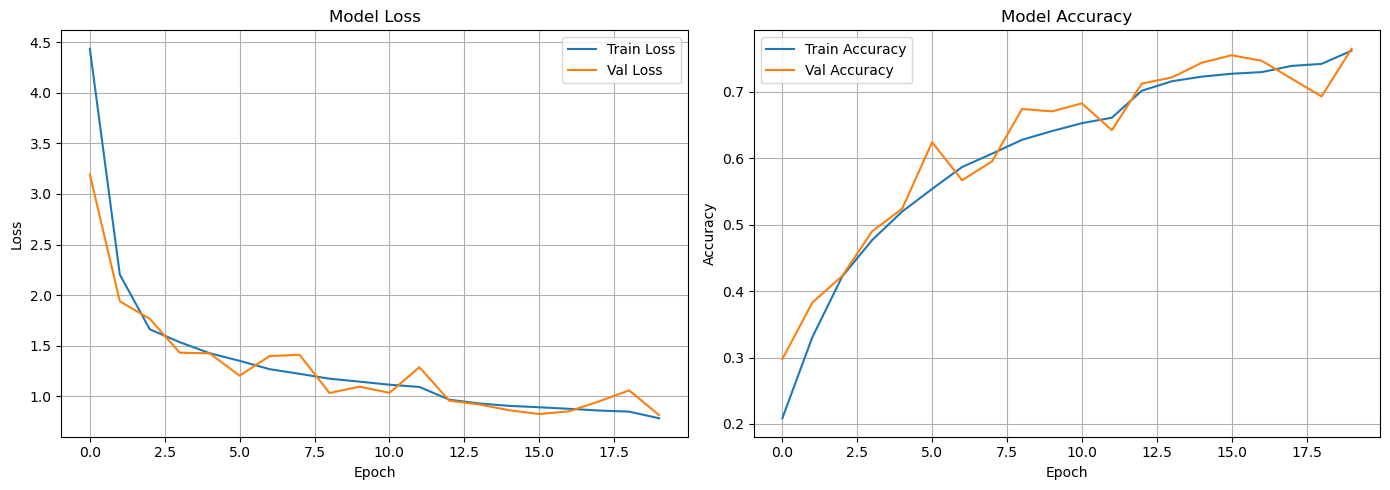

313/313 - 5s - 16ms/step - accuracy: 0.7580 - loss: 0.8385

Test accuracy: 0.7580
Test loss: 0.8385


In [41]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axs[0].plot(history.history["loss"], label="Train Loss")
axs[0].plot(history.history["val_loss"], label="Val Loss")
axs[0].set_title("Model Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)

# Accuracy plot
axs[1].plot(history.history["accuracy"], label="Train Accuracy")
axs[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axs[1].set_title("Model Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate and print test results
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")


